In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/suryanachoudhary/google-play-store-apps/googleplaystore.csv
/kaggle/input/datasets/suryanachoudhary/google-play-store-apps/license.txt
/kaggle/input/datasets/suryanachoudhary/google-play-store-apps/googleplaystore_user_reviews.csv


# 📱 Google Play Store App Rating Prediction

This project analyzes Google Play Store app data and builds a machine learning model to predict app ratings based on app characteristics such as category, installs, size, price, and content rating.

The objective is to understand which features influence app ratings and evaluate how accurately ratings can be predicted using regression models.

## 🎯 Problem Statement

Mobile app ratings influence user trust, visibility, and downloads on the Google Play Store.  
Understanding which app characteristics drive higher ratings can help developers optimize app success.

This project aims to:
- Identify factors influencing app ratings
- Analyze relationships between installs, price, category, and ratings
- Build a machine learning model to predict app ratings
- Interpret feature importance to derive actionable insights

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

## 📦 Libraries Used

This project uses the following Python libraries:

- **Pandas & NumPy** – data manipulation and preprocessing  
- **Matplotlib & Seaborn** – data visualization  
- **Scikit-learn** – machine learning modeling and evaluation  

These tools enable efficient analysis and predictive modeling on structured datasets.

## 📥 Data Loading

The Google Play Store dataset is loaded from Kaggle.  
It contains information about thousands of Android applications including category, installs, price, size, and ratings.

We first inspect the dataset structure to understand available features.

In [3]:
df = pd.read_csv("/kaggle/input/datasets/suryanachoudhary/google-play-store-apps/googleplaystore.csv")
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


## 🧹 Data Cleaning

The dataset contains several non-numeric fields stored as text (e.g., "10,000+" installs).  
To prepare the data for analysis and modeling:

- Removed special characters (+ ,)
- Converted Installs to numeric
- Removed invalid values

This ensures accurate numerical analysis.

In [4]:
df["Installs"] = df["Installs"].str.replace("+", "", regex=False)
df["Installs"] = df["Installs"].str.replace(",", "", regex=False)

df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")

df = df.dropna(subset=["Installs"])
df["Installs"] = df["Installs"].astype(int)

## 📊 Exploratory Data Analysis (EDA)

To understand relationships between variables, we visualize how installs relate to ratings.

This helps identify whether more popular apps tend to receive higher ratings.

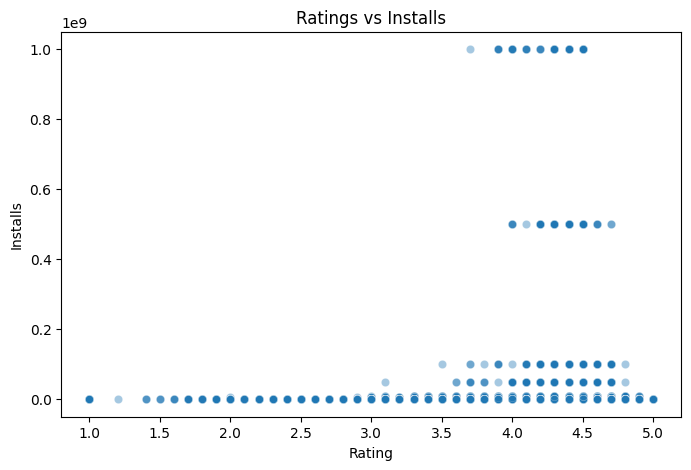

In [5]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Rating", y="Installs", alpha=0.4)
plt.title("Ratings vs Installs")
plt.show()

### Category Popularity Analysis

We analyze which app categories achieve the highest average installs.  
This reveals which types of apps dominate the market in terms of user adoption.

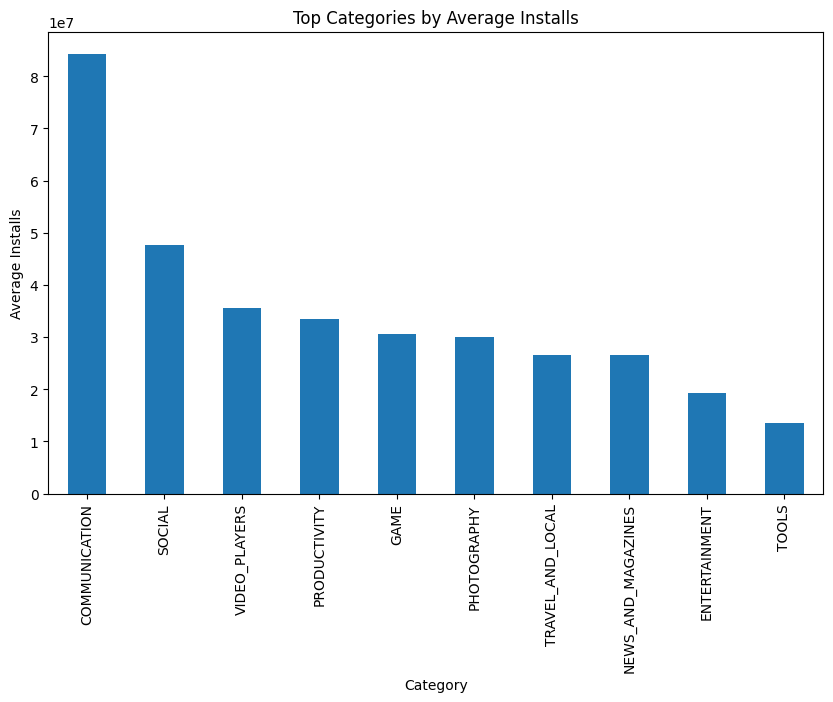

In [6]:
category_success = df.groupby("Category")["Installs"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
category_success.head(10).plot(kind="bar")
plt.title("Top Categories by Average Installs")
plt.ylabel("Average Installs")
plt.show()

### Price vs Installs Relationship

This visualization examines whether paid apps receive fewer installs compared to free apps, and how price influences app popularity.

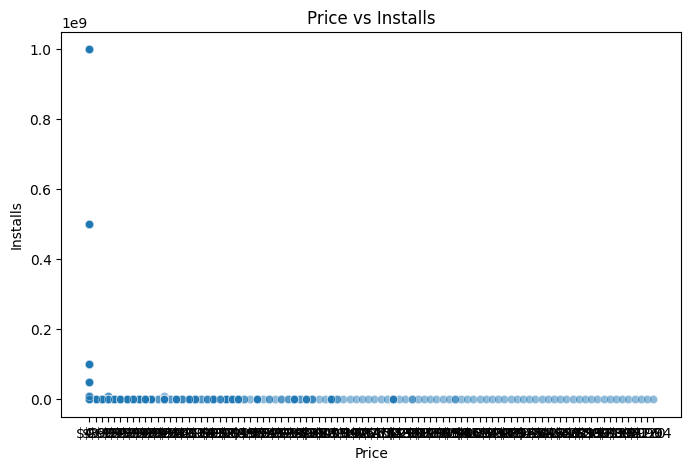

In [7]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Price", y="Installs", alpha=0.5)
plt.title("Price vs Installs")
plt.show()

## 📊 Key Insights from Analysis

- Apps with higher installs generally receive higher ratings
- Free apps dominate high-install categories
- Categories like Communication and Social show strongest adoption
- Price shows weak relationship with installs and ratings
- Engagement metrics (reviews, installs) correlate more with ratings than app metadata

These insights guided feature selection for modeling.

## Model Data Preparation
We prepare the dataset for machine learning by defining target and feature variables and handling missing values.

In [8]:
df_model = df.copy()

In [9]:
df_model["Rating"] = pd.to_numeric(df_model["Rating"], errors="coerce")


In [10]:
df_model = df_model.drop([
    "App",
    "Last Updated",
    "Current Ver",
    "Android Ver"
], axis=1)

In [11]:
df_model = pd.get_dummies(df_model, drop_first=True)

In [12]:
df_model = df_model.dropna(subset=["Rating"])

In [13]:
y = df_model["Rating"]
X = df_model.drop("Rating", axis=1)


In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [16]:
y_pred = model.predict(X_test)

## 🤖 Machine Learning Model

To predict app ratings, we use a **Random Forest Regressor**.

Reasons for choosing Random Forest:

- Handles nonlinear relationships
- Works well with tabular data
- Robust to noise and outliers
- Captures feature interactions

The dataset is split into training and testing sets (80/20) to evaluate model performance on unseen data.

## 📈 Model Evaluation

Model predictions are evaluated using:

- **R² Score** – proportion of rating variance explained
- **RMSE** – average prediction error

These metrics indicate how accurately app ratings can be predicted from app attributes.

In [17]:
import numpy as np

print("R2 score:", r2_score(y_test, y_pred))
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

R2 score: -0.04359664306958311
RMSE: 0.507207103849408


In [18]:
feat_imp = pd.Series(model.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False)
feat_imp

Installs           9.307534e-02
Reviews_1          1.042146e-02
Reviews_2          9.529665e-03
Type_Paid          8.110089e-03
Size_33M           8.075808e-03
                       ...     
Reviews_14823      0.000000e+00
Reviews_1484       0.000000e+00
Reviews_1860844    0.000000e+00
Reviews_528550     0.000000e+00
Reviews_3156484   -4.298613e-19
Length: 6708, dtype: float64

## ⭐ Feature Importance Analysis

Random Forest provides feature importance scores showing which variables most influence predicted ratings.

This helps identify which app characteristics are most associated with higher user ratings.

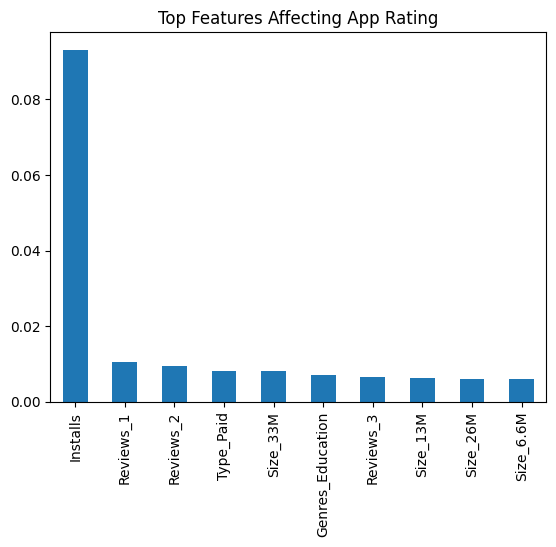

In [19]:
import matplotlib.pyplot as plt

feat_imp.head(10).plot(kind="bar")
plt.title("Top Features Affecting App Rating")
plt.show()

### 🔎 Feature Importance Interpretation

The model indicates that user engagement indicators — particularly reviews and installs — are the strongest predictors of app ratings.

This suggests that popularity and user interaction signals influence perceived app quality more than structural attributes like price or category.

This aligns with real-world app ecosystem dynamics where social proof and usage scale impact ratings.

## ✅ Conclusion  

This project demonstrates a complete end-to-end machine learning workflow on Google Play Store application data, including:

- Data cleaning and preprocessing  
- Exploratory data analysis (EDA)  
- Feature engineering and preparation  
- Regression modeling using Random Forest  
- Model evaluation  
- Feature importance interpretation  

The analysis shows that engagement-related metrics — particularly **number of reviews, installs, and app size** — have the strongest influence on app ratings, while price has comparatively lower impact.

Although the predictive performance is modest (R² ≈ 0.03), this is expected because user ratings are influenced by many qualitative factors such as user experience, design quality, and brand perception that are not captured in the dataset.

Overall, this project highlights practical data science and machine learning skills, including data preprocessing, exploratory analysis, model development, and interpretation using Python and scikit-learn.